# 2023년 의료기관별 시군구별 진료비 분석

## 단계: 02. 탐색적 데이터 분석 (EDA)
- 목표: 데이터의 분포와 변수간의 관계를 시각적으로 이해   

### 2.1 환경 설정 및 파생 변수 생성

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats

df = pd.read_csv(r'C:\data\hira_sigungu_2023.csv', encoding = 'cp949')

In [3]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
# 파생변수 생성
df['1인당_진료비_만원'] = (df['요양급여비용총액(선별포함)'] / df['환자수'] / 10000).round(1)
df['1인당_내원일수'] = (df['입내원일수'] / df['환자수']).round(2)
df['진료비_억원'] = (df['요양급여비용총액(선별포함)'] / 1e8).round(1)
df['log_진료비'] = np.log1p(df['요양급여비용총액(선별포함)'])
df['1인당_진료비'] = (df['요양급여비용총액(선별포함)'] / df['환자수']).round(0)

### 2.2 주요 지표 상위 지역 탐색 (Top 10)

In [6]:
print(df[['시도', '시군구', '1인당_진료비_만원', '1인당_내원일수']].sort_values('1인당_진료비_만원', ascending=False).head(10))

     시도   시군구  1인당_진료비_만원  1인당_내원일수
196  전남   화순군       280.6     14.22
30   부산  부산서구       189.6      9.13
71   울산  울산동구       156.2     12.38
9    서울  서대문구       150.0      8.04
175  전북   익산시       144.0     17.09
51   대구  대구남구       140.4      8.64
238  경남   진주시       132.8     14.26
60   광주  광주동구       132.3      8.04
218  경북   안동시       131.3     13.72
69   대전  대전중구       128.0     10.10


In [4]:
df[['시도', '시군구', '1인당_진료비_만원', '1인당_내원일수']].sort_values('1인당_진료비_만원', ascending=False).head(10)

,시도,시군구,1인당_진료비_만원,1인당_내원일수
196,전남,화순군,280.6,14.22
30,부산,부산서구,189.6,9.13
71,울산,울산동구,156.2,12.38
9,서울,서대문구,150.0,8.04
175,전북,익산시,144.0,17.09
51,대구,대구남구,140.4,8.64
238,경남,진주시,132.8,14.26
60,광주,광주동구,132.3,8.04
218,경북,안동시,131.3,13.72
69,대전,대전중구,128.0,10.10


### 2.3 지역별(시도) 진료비 분포 분석

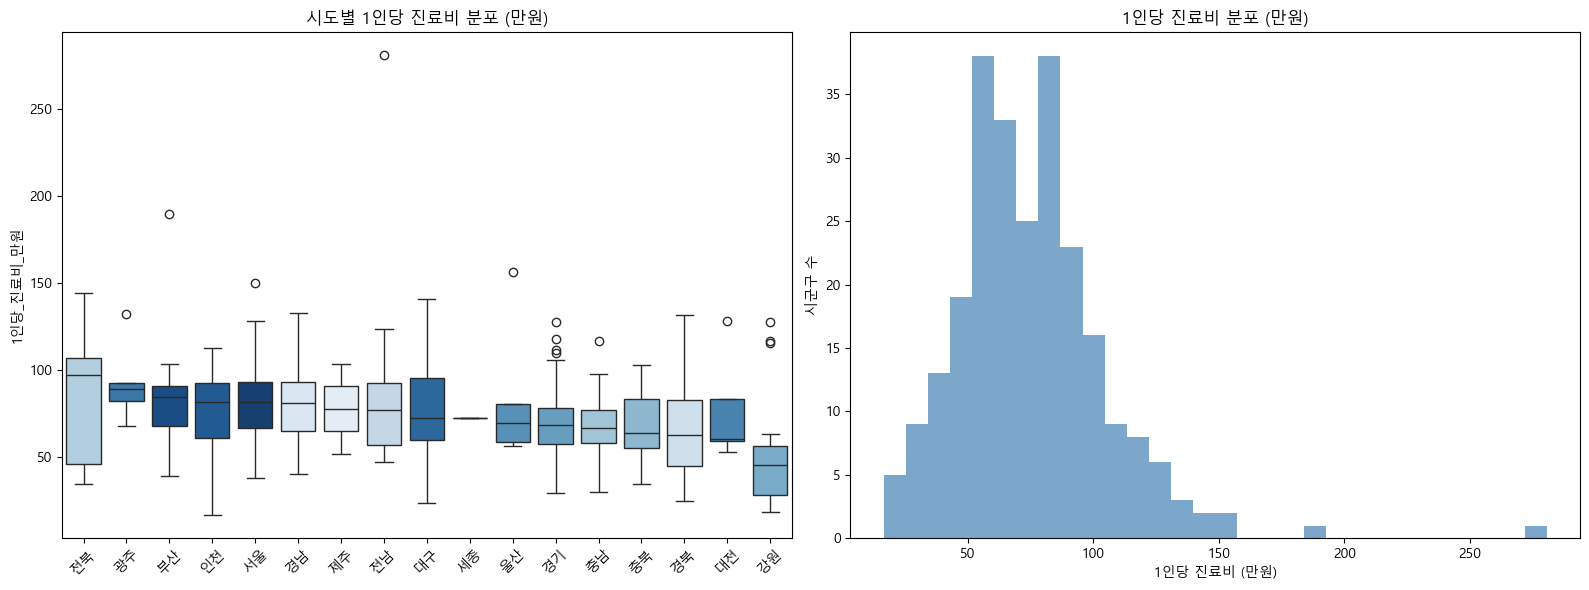

In [5]:
# 시도별 1인당 진료비
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시도별 중앙값 기준 정렬
order = (df.groupby('시도')['1인당_진료비_만원']
           .median()
           .sort_values(ascending=False)
           .index)

sns.boxplot(data=df, x='시도', y='1인당_진료비_만원',
            order=order, ax=axes[0], palette='Blues_r',
           hue='시도')
axes[0].set_title('시도별 1인당 진료비 분포 (만원)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# 진료비 분포
axes[1].hist(df['1인당_진료비_만원'], bins=30,
            color='steelblue', alpha=0.7, label='원본')
axes[1].set_title('1인당 진료비 분포 (만원)')
axes[1].set_xlabel('1인당 진료비 (만원)')
axes[1].set_ylabel('시군구 수')

plt.tight_layout()
plt.savefig(r'C:\data\eda_plot1.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 변수 간 상관관계 및 관계 분석
- 시각화 1. 환자 수 vs 총 진료비 산점도 (Scatter Plot)
- 시각화 2. 주요 변수 간 상관계수 (Correlation)

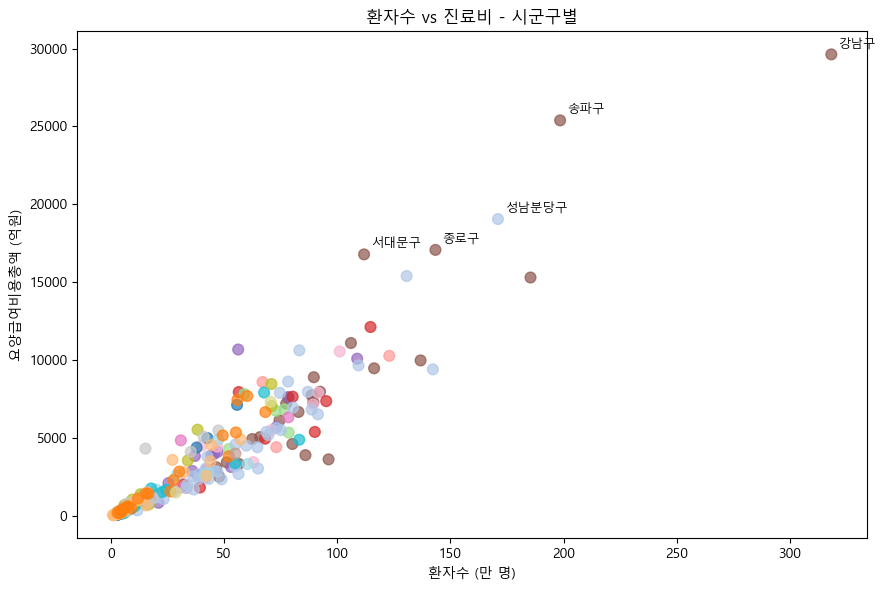

In [6]:
# 환자수 vs 진료비 산점도
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(df['환자수'] / 10000,
                    df['진료비_억원'],
                    c=df['시도'].astype('category').cat.codes,
                    cmap='tab20', alpha=0.7, s=60)

# 상위 5개 시군구 레이블
top5 = df.nlargest(5, '진료비_억원')
for _, row in top5.iterrows():
    ax.annotate(row['시군구'],
               xy=(row['환자수']/10000, row['진료비_억원']),
               xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('환자수 (만 명)')
ax.set_ylabel('요양급여비용총액 (억원)')
ax.set_title('환자수 vs 진료비 - 시군구별')
plt.tight_layout()
plt.savefig(r'C:\data\eda_plot2.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# 상관계수 확인
num_cols = ['환자수', '명세서청구건수', '입내원일수', '진료비_억원', '1인당_진료비_만원']
print(df[num_cols].corr().round(2))

             환자수  명세서청구건수  입내원일수  진료비_억원  1인당_진료비_만원
환자수         1.00     0.95   0.94    0.94        0.35
명세서청구건수     0.95     1.00   1.00    0.90        0.41
입내원일수       0.94     1.00   1.00    0.91        0.44
진료비_억원      0.94     0.90   0.91    1.00        0.54
1인당_진료비_만원  0.35     0.41   0.44    0.54        1.00


In [8]:
df[num_cols].corr().round(2)

,환자수,명세서청구건수,입내원일수,진료비_억원,1인당_진료비_만원
환자수,1.00,0.95,0.94,0.94,0.35
명세서청구건수,0.95,1.00,1.00,0.90,0.41
입내원일수,0.94,1.00,1.00,0.91,0.44
진료비_억원,0.94,0.90,0.91,1.00,0.54
1인당_진료비_만원,0.35,0.41,0.44,0.54,1.00


### 2.5 시도별 요약 통계 및 비교

In [9]:
# EDA 1 : 진료비 상위 5개 시군구
print("▶ 총 진료비 상위 5개 시군구")
print(df.nlargest(5, '요양급여비용총액(선별포함)')[
    ['시도', '시군구', '진료비_억원', '환자수', '1인당_진료비']
].to_string(index=False))

▶ 총 진료비 상위 5개 시군구
시도   시군구  진료비_억원     환자수   1인당_진료비
서울   강남구 29623.5 3182688  930771.0
서울   송파구 25385.4 1984817 1278980.0
경기 성남분당구 19049.1 1710142 1113889.0
서울   종로구 17066.9 1434102 1190073.0
서울  서대문구 16779.4 1118858 1499686.0


In [10]:
# EDA 2 : 시도별 1인당 진료비 평균
sido_mean = (df.groupby('시도')['1인당_진료비']
            .mean()
            .round(0)
            .sort_values(ascending=False))
print('\n▶ 시도별 1인당 평균 진료비 (원)')
print(sido_mean)


▶ 시도별 1인당 평균 진료비 (원)
시도
광주    926887.0
전남    871400.0
부산    856898.0
울산    842205.0
전북    835116.0
서울    830685.0
경남    812343.0
제주    777204.0
대전    767272.0
인천    764370.0
대구    758041.0
세종    724081.0
경기    702277.0
충남    686266.0
충북    660925.0
경북    651542.0
강원    527409.0
Name: 1인당_진료비, dtype: float64


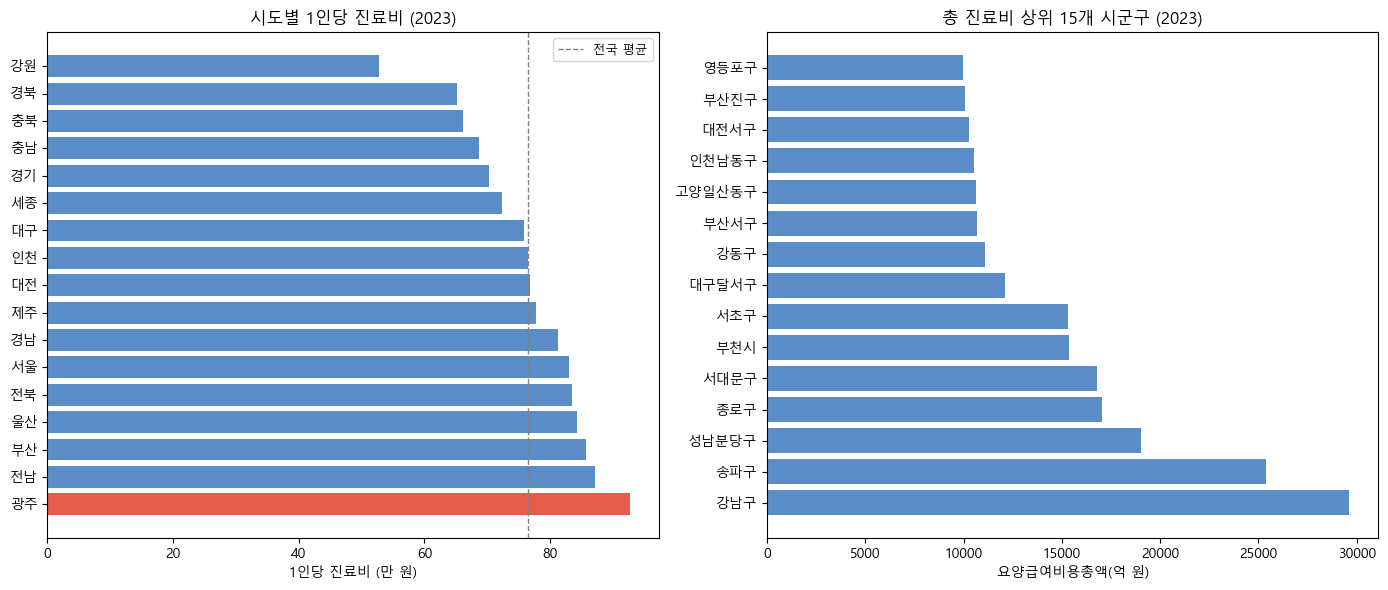

저장완료: eda_plot1.png


In [11]:
# EDA 3 : 시도별 1인당 진료비
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 왼쪽 : 시도별 1인당 진료비
colors = ['#E55C4A' if v == sido_mean.max() else '#5A8CC8' for v in sido_mean.values]
axes[0].barh(sido_mean.index, sido_mean.values / 1e4, color=colors)
axes[0].set_xlabel('1인당 진료비 (만 원)')
axes[0].set_title('시도별 1인당 진료비 (2023)')
axes[0].axvline(sido_mean.mean() / 1e4, color='gray',
                linestyle='--', linewidth=1, label='전국 평균')
axes[0].legend(fontsize=9)

# 오른쪽 : 총 진료비 상위 15개 시군구
top15 = df.nlargest(15, '진료비_억원')
axes[1].barh(top15['시군구'], top15['진료비_억원'], color='#5A8CC8')
axes[1].set_xlabel('요양급여비용총액(억 원)')
axes[1].set_title('총 진료비 상위 15개 시군구 (2023)')

plt.tight_layout()
plt.savefig(r'C:\data\eda_plot1.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장완료: eda_plot1.png')

In [12]:
# 시도별 집계
sido_agg = df.groupby('시도').agg(
    평균_1인당_진료비=('1인당_진료비_만원', 'mean'),
    총진료비_억원=('진료비_억원','sum'),
    시군구수=('시군구','count')
).round(1).sort_values('평균_1인당_진료비',ascending=False)
print(sido_agg)

    평균_1인당_진료비   총진료비_억원  시군구수
시도                            
광주        92.7   30984.6     5
전남        87.1   28372.6    22
부산        85.7   67035.9    16
울산        84.2   17464.9     5
전북        83.5   30600.0    15
서울        83.1  228522.1    25
경남        81.2   50356.1    22
제주        77.8    8810.9     2
대전        76.7   27506.3     5
인천        76.4   44876.6    10
대구        75.8   49235.1     9
세종        72.4    3988.0     1
경기        70.2  190608.1    42
충남        68.6   27028.1    16
충북        66.1   21219.5    14
경북        65.2   30180.5    24
강원        52.7   20808.8    18


In [13]:
sido_agg

,평균_1인당_진료비,총진료비_억원,시군구수
시도,,,
광주,92.7,30984.6,5
전남,87.1,28372.6,22
부산,85.7,67035.9,16
울산,84.2,17464.9,5
전북,83.5,30600.0,15
서울,83.1,228522.1,25
경남,81.2,50356.1,22
제주,77.8,8810.9,2
대전,76.7,27506.3,5


### 2.6 데이터 분포의 왜곡 검토 및 로그 변환
- 통계적 분석과 모델링을 위해 데이터의 왜도(Skewness)를 확인합니다.

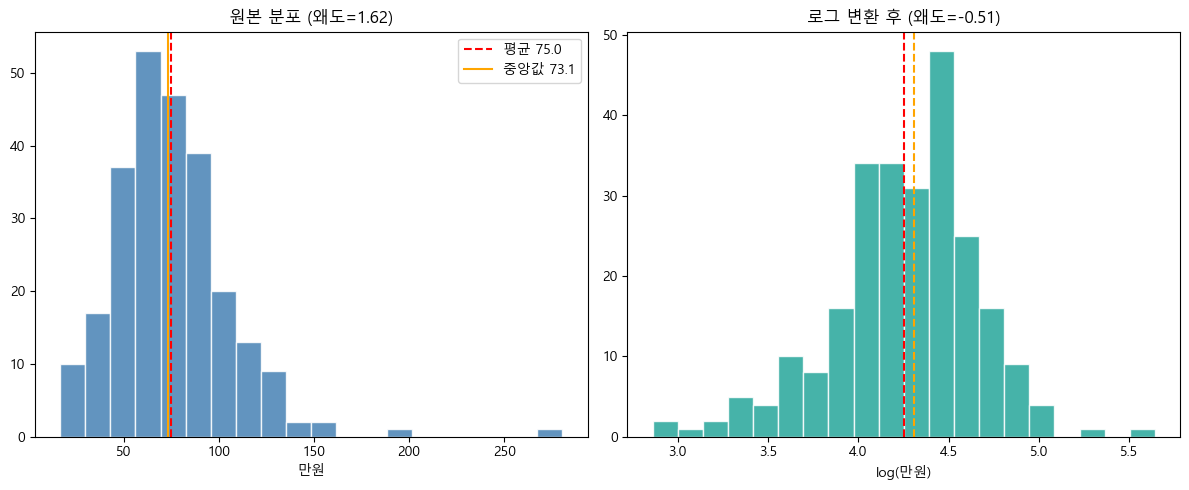

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# 원본 분포
sk = stats.skew(df['1인당_진료비_만원'])
mean_v = df['1인당_진료비_만원'].mean()
med_v = df['1인당_진료비_만원'].median()

axes[0].hist(df['1인당_진료비_만원'],
            bins=20, color='steelblue',
            edgecolor='white', alpha=0.85)
axes[0].axvline(mean_v, color='red',
                linestyle='--', lw=1.5,
                label=f'평균 {mean_v:.1f}')
axes[0].axvline(med_v, color='orange',
                label=f'중앙값 {med_v:.1f}')
axes[0].set_title(
    f'원본 분포 (왜도={sk:.2f})')
axes[0].set_xlabel('만원')
axes[0].legend()

# 로그 변환 후
df['log_1인당'] = np.log1p(df['1인당_진료비_만원'])
sk_log = stats.skew(df['log_1인당'])

axes[1].hist(df['log_1인당'],
            bins=20, color='#26A69A',
            edgecolor='white', alpha=0.85)
axes[1].axvline(df['log_1인당'].mean(),
               color='red', linestyle='--', lw=1.5)
axes[1].axvline(df['log_1인당'].median(),
                color='orange', linestyle='--', lw=1.5)
axes[1].set_title(
    f'로그 변환 후 (왜도={sk_log:.2f})')
axes[1].set_xlabel('log(만원)')

plt.tight_layout()
plt.savefig('eda_dist.png', dpi=150)
plt.show()

> **왜도 1.619의 의미** <br>
> 대부분의 시군구(145개)는 50~90만원 구간에 몰려 있는데, 화순군 한 곳(280.6만원)이 평균을 끌어올립니다. 이런 분포에서는 평균보다 중앙값(73.1만원)이 더 정확한 대표값이고, 회귀분석에 투입할 때는 반드시 log 변환 컬럼을 써야 합니다.

> **이상치 6개 시군구의 공통점** <br>
> 모두 지역 거점 대형병원이 있다는 점입니다. 그 중 보험자부담률 수치가 눈여겨 볼만 합니다. 화순군은 84.9%로 전국 최고인데, 이는 중증질환 환자가 많을수록 건강보험 보장이 더 두텁게 적용된다는정책 설계가 그대로 데이터에 반영된 것입니다. 단순히 '비싼 지역'이 아닌 '보장이 더필요한 중증 환자 집중 지역'이라는 인사이트로 이어집니다.

> **상위 10개 시군구** - '의료 중심지'패턴
> 1인당 진료비 상위권은 모두 대학 병원이 있는 지역 거점입니다. 화순군(전남대병원), 부산서구(부산대병원), 서대문구(연세대병원, 이화여대병원), 익산시(원광대병원), 진주시(경상대병원), 안동시(안동병원)처럼 지역 거점 대학병원이 있는 시군구가 일관되게 상위에 나타납니다. 1인당 진료비는 '돈을 많이 쓰는 지역'이 아니라 '중증 환자가 모이는 지역'을 의미합니다.

> **시도별 집계** - 서울이 1위가 아닌 이유
> 총 진료비는 서울(22.9조)이 압도적이지만, 1인당 기준으로는 광주(92.7만원), 전남(87.1만원), 부산(85.7만원)이 앞섭니다. 서울은 환자 수(2,584만 명)가 워낙 많아 1인당 수치가 희석됩니다. 시도 단위에서는 인구 규모가 큰 경기도(42개 시군구)가 평균을 낮추는 희석 효과도 발생합니다.

> **강원도가 최하위인 이유** - 공급 부족 vs 수요 부족
> 강원도 하위 5개(화천, 양양, 고성, 인제, 평창)는 모두 인구 3만명 이하의 산간 군 지역입니다. 이 지역의 낮은 1인당 진료비는 '건강한 인구'가 아니라 의료기관 접근성 부족으로 해석해야 합니다. 아픈데도 병원을못 가는 상황이 수치에 반영되는 것입니다.    

In [1]:
# 학습 기록

# 1. '총 진료비'와 '1인당 진료비'의 차이
#    - 서울은 총 진료비 규모는 가장 크지만, 1인당으로 계산하면 광주나 전남보다 낮게 나타나기도 합니다. 
#    - 인구수가 많은 지역은 수치가 희석될 수 있다는 점을 배웠습니다.

# 2. 숫자가 말해주는 지역 의료의 현실
#    - 1인당 진료비가 높은 지역(화순, 부산 서구 등)은 대부분 큰 대학병원이 있는 곳이었습니다. 
#    - 반면, 강원도 산간 지역처럼 수치가 낮은 곳은 의료 접근성이 낮아 병원에 가기 힘든 상황이 반영된 것일 수도 있겠다는 생각이 들었습니다.

# 3. 통계적 처리가 필요한 이유
#    - 데이터가 한쪽으로 심하게 쏠려(왜도 1.62) 있어서, 평균값이 실제 대다수 지역의 상황을 대표하기 어렵다는 것을 알게 되었습니다. 
#    - 이를 해결하기 위해 로그 변환을 해보니 분포가 훨씬 안정적으로 변하는 과정을 직접 확인했습니다.